# Carga alostática en personal de bomberos
### Biomarcadores, variabilidad de frecuencia cardiaca (HRV) y resiliencia — Fase 1 vs Fase 2

**Proyecto:** investigación doctoral sobre fisiología del estrés ocupacional en un cuerpo de bomberos.
**Cohorte:** n = 26 elementos, evaluados en dos momentos (Fase 1 y Fase 2).
**Dominios medidos:**

| Dominio | Variables | Descripción |
|---|---|---|
| Biomarcadores | 15 | Signos vitales y bioquímica sanguínea (presión arterial, perfil lipídico, glucosa, cortisol, IL-6, PCR, etc.) |
| HRV supina | 9 | Variabilidad de frecuencia cardiaca en posición supina |
| HRV de pie | 9 | Las mismas 9 variables en posición de pie (respuesta ortostática) |
| Resiliencia | 1 | Puntaje promedio de la Brief Resilience Scale (BRS) |

**Nota de privacidad:** los datos usados en este notebook ya están anonimizados — los identificadores
originales fueron reemplazados por códigos `P01`–`P32` antes de guardarse en `data/cohorte_anonimizada.csv`.
Ningún nombre se procesa ni se muestra en ningún punto de este análisis.

Una versión interactiva de estas mismas figuras (con selector de sujeto y tooltips) vive en
[`docs/index.html`](../docs/index.html), pensada como dashboard de portafolio.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Paleta compartida con el dashboard interactivo (docs/index.html), validada para
# ser distinguible en daltonismo (deltaE CVD >= 8, OKLab) y legible en ambos temas.
COLOR_F1     = "#2a78d6"   # azul  -> Fase 1
COLOR_F2     = "#eb6834"   # naranja -> Fase 2
COLOR_SUPINA = "#2a78d6"
COLOR_DEPIE  = "#1baf7a"   # aqua  -> posición de pie
COLOR_POS    = "#2a78d6"   # correlación positiva
COLOR_NEG    = "#e34948"   # correlación negativa
COLOR_MID    = "#f0efec"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

df = pd.read_csv("../data/cohorte_anonimizada.csv")
print(f"Sujetos: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()


Sujetos: 26  |  Columnas: 71


,sujeto,edad,genero,INDICE_CINTURA_F1,INDICE_CINTURA_F2,BMI_F1,BMI_F2,SISTOLICA_F1,SISTOLICA_F2,DIASTOLICA_F1,...,sup_HF_F1,sup_HF_F2,st_HF_F1,st_HF_F2,sup_LFHF_F1,sup_LFHF_F2,st_LFHF_F1,st_LFHF_F2,BRS_F1,BRS_F2
0,P01,21,M,0.960,1.040,25.5,26.13,110.0,110.0,70.0,...,59797.74,3890.99,26266.15,4331.530863,5.15,15.89,6.09,15.926554,3.500000,4.666667
1,P04,25,M,0.971,0.971,28.3,35.30,160.0,160.0,90.0,...,125993.43,33079.91,171205.97,24453.650060,5.65,5.24,3.15,10.639892,4.166667,3.666667
2,P05,22,M,0.955,0.955,29.2,30.69,130.0,130.0,90.0,...,120638.28,212172.58,169377.01,89417.658710,5.34,1.39,7.29,13.633498,3.666667,4.000000
3,P07,22,M,0.974,0.974,36.3,38.06,130.0,130.0,80.0,...,81166.96,155662.36,275063.20,161061.595500,4.74,2.35,3.12,10.091086,3.166667,3.833333
4,P08,28,M,0.979,0.979,23.9,24.67,110.0,110.0,70.0,...,200868.61,65280.65,268386.20,183709.811500,2.21,4.27,3.07,4.304661,3.500000,3.500000


## 1. Normalización (mín-máx) de biomarcadores y HRV

Cada variable se reescala a `[0, 1]` usando el rango observado conjunto de Fase 1 y Fase 2, para poder comparar unidades muy distintas (mmHg, mg/dL, ms, pg/mL...) en un mismo gráfico (radar, mapa de calor, *dumbbell*). El valor crudo con sus unidades reales se conserva para las anotaciones e interpretación clínica.

In [2]:
BIOMARCADORES = ["INDICE_CINTURA", "BMI", "SISTOLICA", "DIASTOLICA", "F_CARDIACA",
                  "COLESTEROL", "TRIGLICERIDOS", "HDL", "LDL", "ALBUMINA",
                  "GLUCOSA", "IL6", "CORTISOL", "H_GLICOSILADA", "PCR"]
HRV_VARS = ["SDNN", "RMSSD", "lnRMSSD", "SD1", "SD2", "MeanHR", "LF", "HF", "LFHF"]

def minmax_norm(df, base_cols):
    """Normaliza cada par F1/F2 usando el rango conjunto de ambas fases."""
    out = pd.DataFrame(index=df.index)
    for col in base_cols:
        c1, c2 = f"{col}_F1", f"{col}_F2"
        lo = df[[c1, c2]].min().min()
        hi = df[[c1, c2]].max().max()
        span = (hi - lo) if hi > lo else 1.0
        out[f"{col}_F1_norm"] = (df[c1] - lo) / span
        out[f"{col}_F2_norm"] = (df[c2] - lo) / span
    return out

bio_norm = minmax_norm(df, BIOMARCADORES)
sup_norm = minmax_norm(df, [f"sup_{v}" for v in HRV_VARS])
st_norm  = minmax_norm(df, [f"st_{v}" for v in HRV_VARS])

lo, hi = df[["BRS_F1", "BRS_F2"]].min().min(), df[["BRS_F1", "BRS_F2"]].max().max()
brs_norm = pd.DataFrame({
    "BRS_F1_norm": (df["BRS_F1"] - lo) / (hi - lo),
    "BRS_F2_norm": (df["BRS_F2"] - lo) / (hi - lo),
})

norm = pd.concat([df[["sujeto", "edad", "genero"]], bio_norm, sup_norm, st_norm, brs_norm], axis=1)
norm.head(3)


,sujeto,edad,genero,INDICE_CINTURA_F1_norm,INDICE_CINTURA_F2_norm,BMI_F1_norm,BMI_F2_norm,SISTOLICA_F1_norm,SISTOLICA_F2_norm,DIASTOLICA_F1_norm,...,st_MeanHR_F1_norm,st_MeanHR_F2_norm,st_LF_F1_norm,st_LF_F2_norm,st_HF_F1_norm,st_HF_F2_norm,st_LFHF_F1_norm,st_LFHF_F2_norm,BRS_F1_norm,BRS_F2_norm
0,P01,21,M,0.587629,1.000000,0.290224,0.322301,0.038462,0.038462,0.25,...,0.498172,0.833246,0.049292,0.011225,0.081362,0.009954,0.092469,0.391672,0.307692,0.846154
1,P04,25,M,0.644330,0.644330,0.432790,0.789206,1.000000,1.000000,0.75,...,0.700966,0.695221,0.207947,0.091184,0.553213,0.075462,0.003042,0.230865,0.615385,0.384615
2,P05,22,M,0.561856,0.561856,0.478615,0.554481,0.423077,0.423077,0.75,...,0.279838,0.249674,0.498462,0.492191,0.547259,0.286952,0.128970,0.321923,0.384615,0.538462


## 2. Panorama de la cohorte

In [3]:
kpis = {
    "n_sujetos": len(df),
    "edad_promedio": round(df["edad"].mean(), 1),
    "pct_masculino": round((df["genero"] == "M").mean() * 100, 1),
    "brs_f1_promedio": round(df["BRS_F1"].mean(), 2),
    "brs_f2_promedio": round(df["BRS_F2"].mean(), 2),
    "pct_mejora_resiliencia": round((df["BRS_F2"] > df["BRS_F1"]).mean() * 100, 1),
}
for k, v in kpis.items():
    print(f"{k:28s}: {v}")


n_sujetos                   : 26
edad_promedio               : 25.0
pct_masculino               : 84.6
brs_f1_promedio             : 3.75
brs_f2_promedio             : 3.68
pct_mejora_resiliencia      : 38.5


## 3. Correlación entre biomarcadores, HRV y resiliencia

Coeficiente de Pearson sobre un conjunto curado de variables representativas de cada dominio (en Fase 1, normalizadas). El objetivo es explorar si la resiliencia autorreportada (BRS) se asocia con marcadores fisiológicos de estrés — sin asumir causalidad, y con la cautela que exige un n = 26.

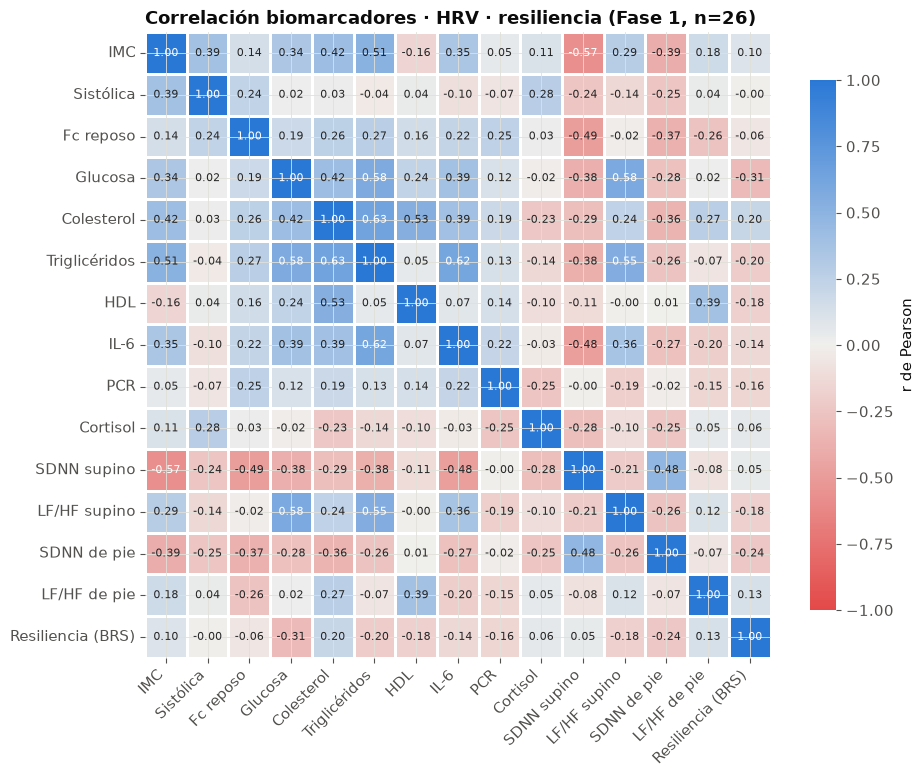

Variable más asociada a la resiliencia: Glucosa  (r = -0.31)


In [4]:
curated_cols = {
    "IMC": "BMI_F1_norm", "Sistólica": "SISTOLICA_F1_norm", "Fc reposo": "F_CARDIACA_F1_norm",
    "Glucosa": "GLUCOSA_F1_norm", "Colesterol": "COLESTEROL_F1_norm", "Triglicéridos": "TRIGLICERIDOS_F1_norm",
    "HDL": "HDL_F1_norm", "IL-6": "IL6_F1_norm", "PCR": "PCR_F1_norm", "Cortisol": "CORTISOL_F1_norm",
    "SDNN supino": "sup_SDNN_F1_norm", "LF/HF supino": "sup_LFHF_F1_norm",
    "SDNN de pie": "st_SDNN_F1_norm", "LF/HF de pie": "st_LFHF_F1_norm",
    "Resiliencia (BRS)": "BRS_F1_norm",
}
corr_df = norm[list(curated_cols.values())].rename(columns={v: k for k, v in curated_cols.items()})
corr_matrix = corr_df.corr(method="pearson")

cmap = mcolors.LinearSegmentedColormap.from_list("diverging", [COLOR_NEG, COLOR_MID, COLOR_POS])
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(corr_matrix, cmap=cmap, vmin=-1, vmax=1, center=0, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=2, linecolor="white",
            cbar_kws={"label": "r de Pearson", "shrink": 0.8}, ax=ax)
ax.set_title("Correlación biomarcadores · HRV · resiliencia (Fase 1, n=26)", loc="left", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

brs_corr = corr_matrix["Resiliencia (BRS)"].drop("Resiliencia (BRS)").abs().sort_values(ascending=False)
top = brs_corr.index[0]
print(f"Variable más asociada a la resiliencia: {top}  (r = {corr_matrix['Resiliencia (BRS)'][top]:.2f})")


## 4. Perfil individual: biomarcadores Fase 1 vs Fase 2

Ejemplo con el sujeto **P01**. El radar compara las 15 variables normalizadas entre ambas fases; el área más extendida hacia un vértice indica un valor más alto (no necesariamente 'mejor' — depende de la variable clínica).

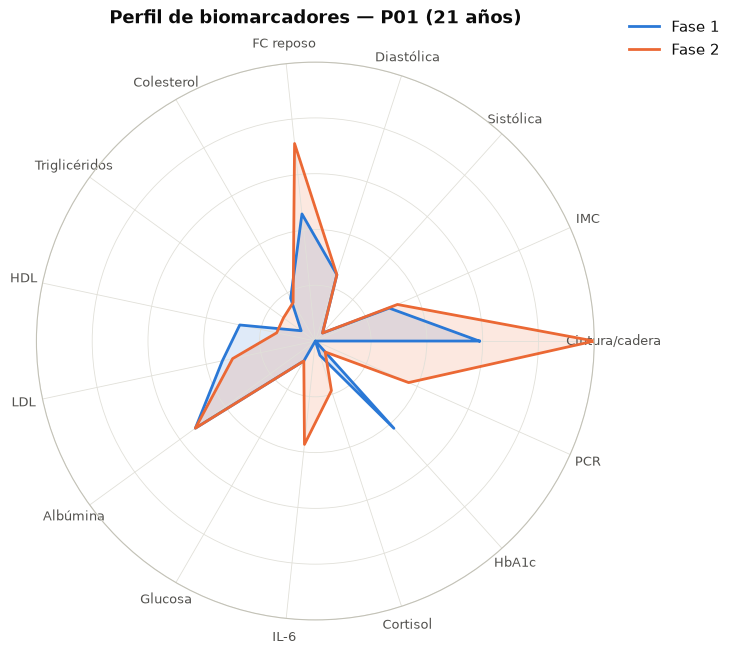

In [5]:
subject_id = "P01"
row = df[df["sujeto"] == subject_id].iloc[0]
row_norm = norm[norm["sujeto"] == subject_id].iloc[0]

labels_short = {"INDICE_CINTURA": "Cintura/cadera", "BMI": "IMC", "SISTOLICA": "Sistólica",
    "DIASTOLICA": "Diastólica", "F_CARDIACA": "FC reposo", "COLESTEROL": "Colesterol",
    "TRIGLICERIDOS": "Triglicéridos", "HDL": "HDL", "LDL": "LDL", "ALBUMINA": "Albúmina",
    "GLUCOSA": "Glucosa", "IL6": "IL-6", "CORTISOL": "Cortisol", "H_GLICOSILADA": "HbA1c", "PCR": "PCR"}

labels = [labels_short[c] for c in BIOMARCADORES]
f1_vals = [row_norm[f"{c}_F1_norm"] for c in BIOMARCADORES]
f2_vals = [row_norm[f"{c}_F2_norm"] for c in BIOMARCADORES]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
f1_vals += f1_vals[:1]; f2_vals += f2_vals[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
ax.plot(angles, f1_vals, color=COLOR_F1, linewidth=2, label="Fase 1")
ax.fill(angles, f1_vals, color=COLOR_F1, alpha=0.15)
ax.plot(angles, f2_vals, color=COLOR_F2, linewidth=2, label="Fase 2")
ax.fill(angles, f2_vals, color=COLOR_F2, alpha=0.15)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([]); ax.set_ylim(0, 1)
ax.set_title(f"Perfil de biomarcadores — {subject_id} ({int(row['edad'])} años)", pad=28, fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
plt.tight_layout()
plt.show()


## 5. Respuesta ortostática (HRV supina vs. de pie)

Mismo sujeto: comparación de las 9 métricas de HRV, normalizadas, entre la posición supina y de pie en Fase 1 — la caída característica de SDNN/RMSSD y el aumento de la frecuencia cardiaca media reflejan la activación simpática al ponerse de pie.

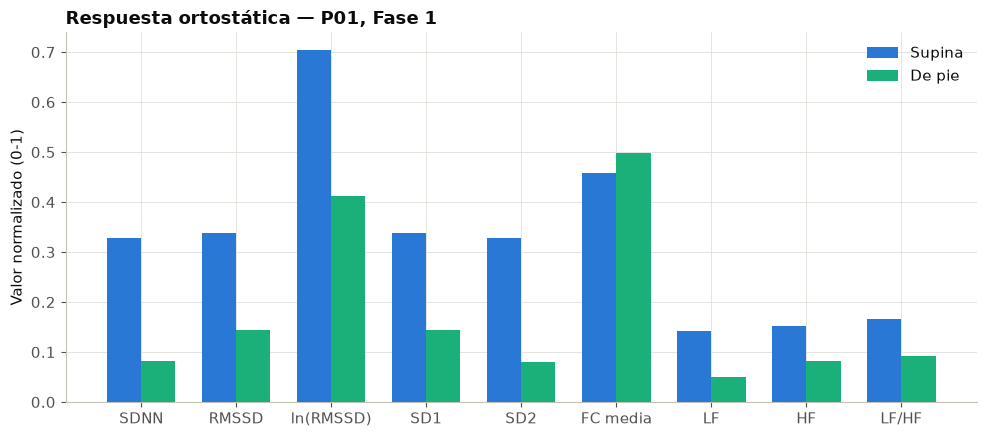

In [6]:
hrv_labels = ["SDNN", "RMSSD", "ln(RMSSD)", "SD1", "SD2", "FC media", "LF", "HF", "LF/HF"]
sup_vals = [row_norm[f"sup_{v}_F1_norm"] for v in HRV_VARS]
st_vals  = [row_norm[f"st_{v}_F1_norm"] for v in HRV_VARS]

x = np.arange(len(hrv_labels)); width = 0.36
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, sup_vals, width, color=COLOR_SUPINA, label="Supina", zorder=3)
ax.bar(x + width/2, st_vals, width, color=COLOR_DEPIE, label="De pie", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(hrv_labels)
ax.set_ylabel("Valor normalizado (0-1)")
ax.set_title(f"Respuesta ortostática — {subject_id}, Fase 1", loc="left", fontsize=13, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 6. Comparación de la cohorte: Fase 1 vs Fase 2

Media normalizada por variable, toda la cohorte (n=26), ordenada por magnitud del cambio. Un *dumbbell chart* deja ver de un vistazo qué variables se movieron más entre fases.

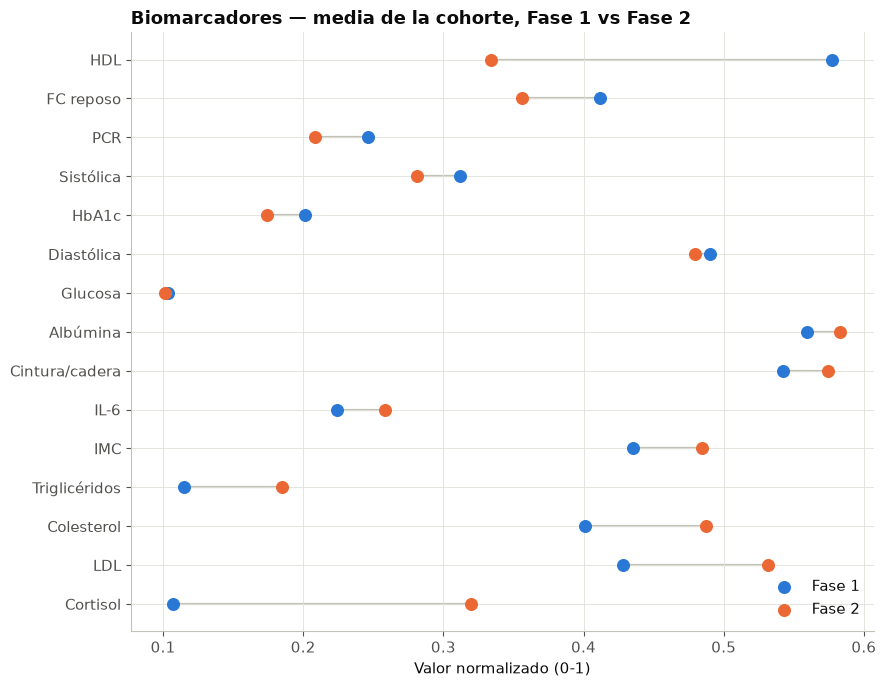

In [7]:
def dumbbell(ax, rows, title):
    rows = sorted(rows, key=lambda r: r[1] - r[2])
    labels = [r[0] for r in rows]
    f1 = [r[1] for r in rows]; f2 = [r[2] for r in rows]
    y = np.arange(len(labels))
    ax.hlines(y, f1, f2, color="#c3c2b7", linewidth=1.6, zorder=1)
    ax.scatter(f1, y, s=70, color=COLOR_F1, zorder=3, label="Fase 1")
    ax.scatter(f2, y, s=70, color=COLOR_F2, zorder=3, label="Fase 2")
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.set_xlabel("Valor normalizado (0-1)")
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.legend(frameon=False, loc="lower right")

rows = [(labels_short[c], norm[f"{c}_F1_norm"].mean(), norm[f"{c}_F2_norm"].mean()) for c in BIOMARCADORES]
fig, ax = plt.subplots(figsize=(9, 7))
dumbbell(ax, rows, "Biomarcadores — media de la cohorte, Fase 1 vs Fase 2")
plt.tight_layout()
plt.show()


## 7. Conclusiones y límites

- La cohorte es pequeña (n = 26); las correlaciones exploratorias (sección 3) deben leerse como
  hipótesis a confirmar, no como hallazgos concluyentes.
- El cambio Fase 1 → Fase 2 es heterogéneo por variable: algunos biomarcadores (cortisol, LDL,
  colesterol total) suben en promedio, mientras que HDL y frecuencia cardiaca bajan — patrón
  consistente con lo esperado en cargas de trabajo prolongadas, pero requiere un análisis
  inferencial (pruebas pareadas) fuera del alcance de este notebook exploratorio.
- El 38.5% de la cohorte mostró mejora en su puntaje de resiliencia (BRS) entre fases; conviene
  cruzar ese subgrupo con los biomarcadores que más cambiaron para explorar mecanismos.
- Próximo paso natural: pruebas de hipótesis pareadas (Wilcoxon) por variable y un modelo
  multivariante (p. ej. PLS o regresión con penalización) dado el n reducido frente al número
  de variables.

**Versión interactiva:** [`docs/index.html`](../docs/index.html) — mismo análisis con selector
de sujeto, tooltips y comparación de dominios en vivo.
